Retrying factor analysis and also probably messing with dataset still but needed new notebook for organiztional sake

In [50]:
import pandas as pd
from src.features import feature_encoder, transformers
from src.utils import data_utils
from src import plots
from sklearn.model_selection import train_test_split
import factor_analyzer
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv("../../data/processed/3.0-jp-eda-df.csv", header=[0, 1, 2])

df_encoded = feature_encoder.encode_features(df.copy(), impute=True)

In [52]:
X = df_encoded.drop(columns=['ahi'])
y = data_utils.convert_ahi(df_encoded['ahi'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

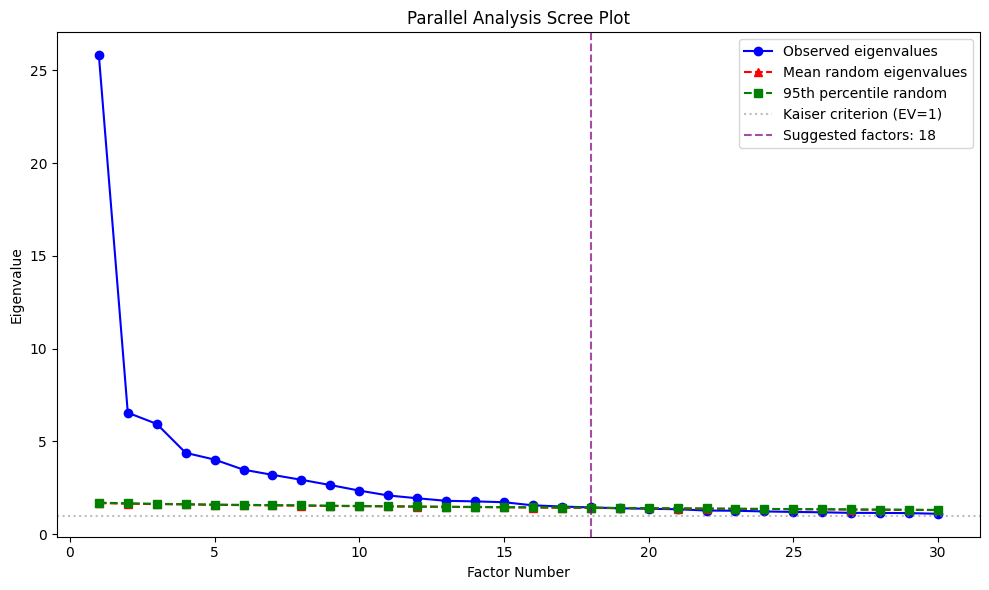


Parallel analysis suggests 18 factors


In [53]:
plots.parallel_analysis(X)

In [54]:
fa = factor_analyzer.FactorAnalyzer(rotation="promax", n_factors=18)
fa.fit(X)

FactorAnalyzer(n_factors=18, rotation_kwargs={})

In [55]:
loadings = fa.loadings_
loadings_df = pd.DataFrame(
    loadings,
    index=X.columns,
    columns=[f"factor_{i+1}" for i in range(fa.n_factors)],
)

for i in range(loadings.shape[1]):
    print(f"Top loadings for factor_{i+1}:")
    print(
        loadings_df[f"factor_{i+1}"].abs().sort_values(ascending=False).head(8)
    )
    print("\n")

Top loadings for factor_1:
fati_interferes_with_phys_function_fss       1.009056
fati_prevents_sustained_phys_func_fss        0.996921
fati_top_three_disabling_sympts_fss          0.939588
fati_interferes_with_responsibilities_fss    0.937367
i_am_easily_fati_fss                         0.904549
fati_causes_freq_probs_for_me_fss            0.888070
fati_interferes_with_work_fam_social_fss     0.817869
lower_motivation_when_fati_fss               0.641299
Name: factor_1, dtype: float64


Top loadings for factor_2:
isi_total_score                                         0.966443
diff_staying_asleep_isi                                 0.938346
how_satisfied_with_curr_sleep_pattern_isi               0.835752
troub_slp_nose                                          0.775619
slp_quality_sw                                          0.729743
frequent_wakenings_map                                  0.640099
sleep_problem_intereferes_with_daily_functioning_isi    0.626896
trouble_sleeping_or_too_mu

In [56]:
import semopy
import re

# Sanitize column names for semopy model syntax (no spaces, parens, etc.)
def sanitize_name(name):
    return re.sub(r"[^a-zA-Z0-9_]", "_", str(name))

name_map = {col: sanitize_name(col) for col in X.columns}
X_test_cfa = X_test.rename(columns=name_map)
loadings_df_cfa = loadings_df.copy()
loadings_df_cfa.index = [name_map[c] for c in loadings_df.index]

# Assign each variable to the factor with the highest absolute loading
LOADING_THRESHOLD = 0.83  # minimum loading to include a variable

factor_assignments = {}
for var in loadings_df_cfa.index:
    row = loadings_df_cfa.loc[var]
    max_loading = row.abs().max()
    if max_loading >= LOADING_THRESHOLD:
        dominant_factor = row.abs().idxmax()
        factor_assignments.setdefault(dominant_factor, []).append(var)

# Build model spec — factors with <2 indicators are dropped (CFA requirement)
model_lines = [
    f"{factor} =~ {' + '.join(indicators)}"
    for factor, indicators in factor_assignments.items()
    if len(indicators) >= 2
]
n_cfa_factors = len(model_lines)
model_spec = "\n".join(model_lines)
print(f"CFA model: {n_cfa_factors} factors, "
      f"{sum(len(v) for v in factor_assignments.values() if len(v) >= 2)} indicators\n")
print(model_spec)

CFA model: 8 factors, 23 indicators

factor_8 =~ nasal_blockage_obstr_nose + troub_brth_nose
factor_9 =~ map_index_4_narcolepsy_like_symptoms_score + hh_frequency_score
factor_6 =~ snorting_gasping_map + map_index_1_apnea_score
factor_2 =~ diff_staying_asleep_isi + how_satisfied_with_curr_sleep_pattern_isi + isi_total_score
factor_3 =~ sleep_affected_work_isq + sleep_affected_your_social_life_isq + sleep_affected_other_important_parts_of_life_isq
factor_4 =~ feeling_anxious_freq_gad + not_able_to_control_worrying_freq_gad + worry_too_much_diff_things_freq_gad
factor_1 =~ i_am_easily_fati_fss + fati_interferes_with_phys_function_fss + fati_causes_freq_probs_for_me_fss + fati_prevents_sustained_phys_func_fss + fati_interferes_with_responsibilities_fss + fati_top_three_disabling_sympts_fss
factor_17 =~ dream_recall_frequency_infrequent + dream_recall_frequency_rarely_or_never


In [57]:
# Fit CFA on the holdout set (X_test) to validate the EFA-derived structure
cfa_model = semopy.Model(model_spec)
cfa_model.fit(X_test_cfa)

# Fit indices
fit_stats = semopy.calc_stats(cfa_model)
print(fit_stats.T)

                      Value
DoF            2.020000e+02
DoF Baseline   2.530000e+02
chi2           3.675476e+02
chi2 p-value   9.587997e-12
chi2 Baseline  5.861351e+03
CFI            9.704819e-01
GFI            9.372930e-01
AGFI           9.214611e-01
NFI            9.372930e-01
TLI            9.630294e-01
RMSEA          5.029366e-02
AIC            1.457382e+02
BIC            4.257412e+02
LogLik         1.130916e+00


In [58]:
# Inspect parameter estimates (loadings, variances, covariances)
display(cfa_model.inspect())

,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,nasal_blockage_obstr_nose,~,factor_8,1.000000,-,-,-
1,troub_brth_nose,~,factor_8,1.334660,0.207099,6.444555,0.0
2,map_index_4_narcolepsy_like_symptoms_score,~,factor_9,1.000000,-,-,-
3,hh_frequency_score,~,factor_9,1.557710,0.118622,13.131699,0.0
4,snorting_gasping_map,~,factor_6,1.000000,-,-,-
...,...,...,...,...,...,...,...
77,sleep_affected_work_isq,~~,sleep_affected_work_isq,0.520741,0.049612,10.496221,0.0
78,sleep_affected_your_social_life_isq,~~,sleep_affected_your_social_life_isq,0.204036,0.034294,5.949547,0.0
79,snorting_gasping_map,~~,snorting_gasping_map,0.775669,0.285726,2.714727,0.006633
80,troub_brth_nose,~~,troub_brth_nose,0.067220,0.15414,0.436099,0.662765


In [59]:
# Key fit indices summary
key_metrics = ["chi2", "dof", "pvalue", "RMSEA", "CFI", "TLI", "SRMR", "AIC", "BIC"]
available = [m for m in key_metrics if m in fit_stats.columns]
print(fit_stats[available].T.to_string())

            Value
chi2   367.547597
RMSEA    0.050294
CFI      0.970482
TLI      0.963029
AIC    145.738169
BIC    425.741232


In [60]:
## Modeling: Baseline vs Factor Analysis (XGBoost)
# Compare raw features vs FA-transformed features using the best XGBoost params from tuning.

In [61]:
from src.modeling import fa_tuning

oblique_rotations = ["promax", "oblimin", "quartimin"]
fa_methods = ["minres", "principal"]

xgb_search_space = {
    "n_estimators": [100, 250, 500, 1000],
    "max_depth": [3, 4, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

tuning_result = fa_tuning.tune_factor_analysis_rotation(
            X,
            y,
            rotations=oblique_rotations,
            methods=fa_methods,
            n_factors=18,
            n_splits=5,
            n_trials=40,
            scoring="average_precision",
            xgb_search_space=xgb_search_space,
            random_state=42,
        )

[I 2026-04-22 20:35:39,575] A new study created in memory with name: no-name-684bd0ca-e671-457d-9369-12820f28b19c
[I 2026-04-22 20:35:59,664] Trial 0 finished with value: 0.6631926438477354 and parameters: {'rotation': 'oblimin', 'method': 'minres', 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 0 with value: 0.6631926438477354.
[I 2026-04-22 20:36:30,061] Trial 1 finished with value: 0.6645830402250199 and parameters: {'rotation': 'quartimin', 'method': 'minres', 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0}. Best is trial 1 with value: 0.6645830402250199.
[I 2026-04-22 20:36:33,887] Trial 2 finished with value: 0.6918481718662872 and parameters: {'rotation': 'oblimin', 'method': 'principal', 'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0}. Best is trial 2 with value: 0.6918481718662872.
[I 2026-04-22 20

In [62]:
best_fa_pipeline = fa_tuning.build_best_factor_analysis_pipeline(tuning_result)

best_fa_pipeline.fit(X_train, y_train)

Pipeline(steps=[('factor_analysis',
                 Factor_Analyzer_Transformer(method='principal')),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1.0, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Using CFA Results with XGBoost

Two approaches:
- **A**: Restrict the FA transformer to only CFA-confirmed indicator variables (CFA-gated feature selection)
- **B**: Use CFA latent factor scores directly as features (semopy predict_factors

In [63]:
# Recover original (unsanitized) column names for CFA-confirmed indicators
reverse_name_map = {v: k for k, v in name_map.items()}

confirmed_sanitized = {
    var for indicators in factor_assignments.values()
    if len(indicators) >= 2
    for var in indicators
}
confirmed_cols = [reverse_name_map[s] for s in confirmed_sanitized if s in reverse_name_map]

print(f"CFA-confirmed features: {len(confirmed_cols)} / {X.shape[1]} total")

CFA-confirmed features: 23 / 148 total


In [64]:
# Option A: FA on ALL features (18 factors) -> XGBoost, using best tuned params
# CFA validates which factors are real, but we still extract all 18 and let XGBoost weight them
from src.features.transformers import Factor_Analyzer_Transformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

best_method = tuning_result.best_method or "minres"
xgb_params = {
    k: v for k, v in tuning_result.best_params.items()
    if k not in {"rotation", "method", "n_factors"}
}

pipeline_a = Pipeline([
    ("fa", Factor_Analyzer_Transformer(
        n_factors=18,
        rotation=tuning_result.best_rotation,
        method=best_method,
    )),
    ("xgb", XGBClassifier(**xgb_params)),
])
pipeline_a.fit(X_train, y_train)
proba_a = pipeline_a.predict_proba(X_test)[:, 1]
print(f"Option A (FA all features, 18 factors, best rotation/method): AP = {average_precision_score(y_test, proba_a):.4f}")

Option A (FA all features, 18 factors, best rotation/method): AP = 0.6868


In [65]:
# Option B: EFA scores on CFA-confirmed columns -> XGBoost
# semopy.predict_factors is numerically unstable with sparse (2-indicator) factors;
# use factor_analyzer's Thomson regression scoring on the confirmed subset instead.

from factor_analyzer import FactorAnalyzer

fa_b = FactorAnalyzer(
    n_factors=n_cfa_factors,
    rotation=tuning_result.best_rotation,
    method=best_method,
)
fa_b.fit(X_train[confirmed_cols])

X_train_b_scores = fa_b.transform(X_train[confirmed_cols])
X_test_b_scores  = fa_b.transform(X_test[confirmed_cols])

xgb_b = XGBClassifier(**xgb_params)
xgb_b.fit(X_train_b_scores, y_train)
proba_b = xgb_b.predict_proba(X_test_b_scores)[:, 1]
print(f"Option B (EFA on CFA-confirmed cols, {n_cfa_factors} factors): AP = {average_precision_score(y_test, proba_b):.4f}")

Option B (EFA on CFA-confirmed cols, 8 factors): AP = 0.6724
